# 6. Otsu Thresholding

## Table of Contents
1. [Libraries](#libraries)
2. [Single Thresholding](#single)
3. [Multi Thresholding](#multi)

Thresholding is used to create a binary image from a grayscale image

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu
import numpy as np

## Single Thresholding <a class="anchor" id="single" ></a>

We illustrate how to apply one of these thresholding algorithms.
Otsu's method [2]_ calculates an "optimal" threshold (marked by a red line in the
histogram below) by maximizing the variance between two classes of pixels,
which are separated by the threshold. Equivalently, this threshold minimizes
the intra-class variance.

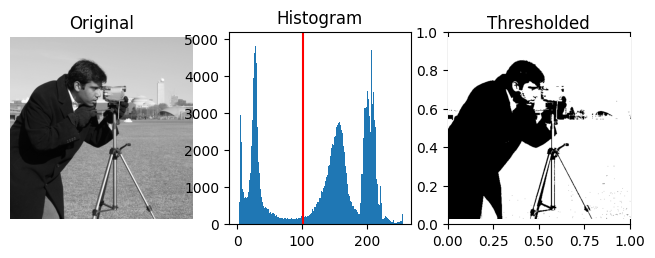

In [2]:
image = data.camera()
thresh = threshold_otsu(image)
binary = image > thresh

fig, axes = plt.subplots(ncols=3, figsize=(8, 2.5))
ax = axes.ravel()
ax[0] = plt.subplot(1, 3, 1)
ax[1] = plt.subplot(1, 3, 2)
ax[2] = plt.subplot(1, 3, 3, sharex=ax[0], sharey=ax[0])

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histogram')
ax[1].axvline(thresh, color='r')

ax[2].imshow(binary, cmap=plt.cm.gray)
ax[2].set_title('Thresholded')
ax[2].axis('off')

plt.show()

If you are not familiar with the details of the different algorithms and the
underlying assumptions, it is often difficult to know which algorithm will give
the best results. Therefore, Scikit-image includes a function to evaluate
thresholding algorithms provided by the library. At a glance, you can select
the best algorithm for your data without a deep understanding of their
mechanisms.




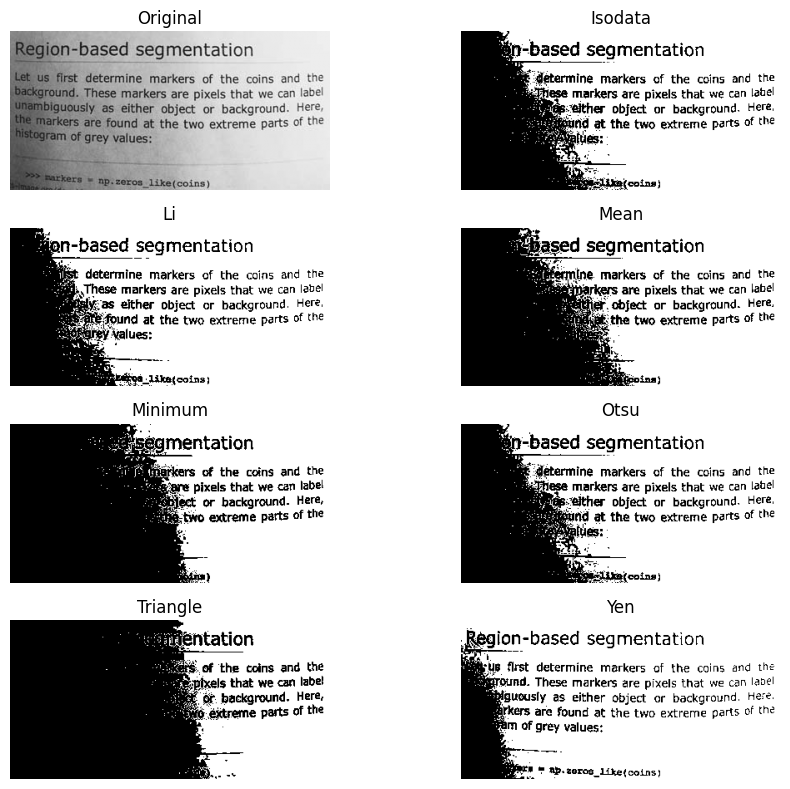

In [3]:
from skimage.filters import try_all_threshold

img = data.page()

fig, ax = try_all_threshold(img, figsize=(10, 8), verbose=False)
plt.show()

In [4]:
# TODO: Slide image for segmentation, alpha blerding

## Multi Thresholding <a class="anchor" id="multi" ></a>

The multi-Otsu threshold  is a thresholding algorithm that is used to separate
the pixels of an input image into several different classes, each one obtained
according to the intensity of the gray levels within the image.

Multi-Otsu calculates several thresholds, determined by the number of desired
classes. The default number of classes is 3: for obtaining three classes, the
algorithm returns two threshold values. They are represented by a red line in
the histogram below.

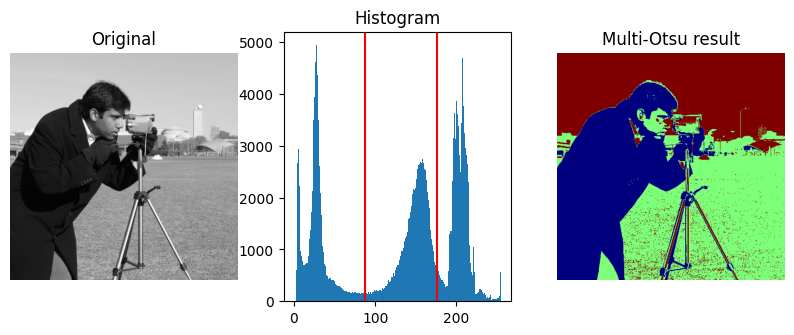

In [5]:
# The input image.
image = data.camera()

# Applying multi-Otsu threshold for the default value, generating
# three classes.
thresholds = threshold_multiotsu(image)

# Using the threshold values, we generate the three regions.
regions = np.digitize(image, bins=thresholds)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3.5))

# Plotting the original image.
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

# Plotting the histogram and the two thresholds obtained from
# multi-Otsu.
ax[1].hist(image.ravel(), bins=255)
ax[1].set_title('Histogram')
for thresh in thresholds:
    ax[1].axvline(thresh, color='r')

# Plotting the Multi Otsu result.
ax[2].imshow(regions, cmap='jet')
ax[2].set_title('Multi-Otsu result')
ax[2].axis('off')

plt.subplots_adjust()

plt.show()

# Experimentos de la actividad

La actividad pide (1) **experimentar con imágenes de fondos y estilos distintos** y ver las limitaciones de un umbral único frente a Otsu, y (2) de forma opcional, **aplicar Otsu por ventanas** con el ejemplo de la hoja de papel.

1. [Herramientas: medida de eficacia de Otsu](#eta)
2. [Un umbral único frente a Otsu](#unico): imágenes con distinta iluminación
3. [Imágenes de fondos y estilos distintos](#estilos)
4. [Opcional: Otsu por ventanas sobre una hoja con sombras](#local)
5. [Conclusión](#conclusion)

<a id="eta"></a>
## 1. Medida de eficacia de Otsu

Otsu elige el umbral $k^*$ que maximiza la **varianza entre clases** $\sigma_B^2(k) = \omega_0(k)\,\omega_1(k)\,[\mu_0(k) - \mu_1(k)]^2$, donde $\omega_i$ y $\mu_i$ son la proporción y la media de cada clase. El propio artículo (Otsu, 1979) propone una **medida de separabilidad** $\eta = \sigma_B^2(k^*) / \sigma_T^2 \in [0, 1]$, la fracción de la varianza total que explican las dos clases:
un valor cercano a 1 indica un histograma claramente bimodal (Otsu funciona bien); un valor bajo, que las dos clases no están bien separadas por intensidad (Otsu puede fallar).

In [6]:
import cv2, numpy as np, matplotlib.pyplot as plt, time
from skimage import data
from skimage.filters import threshold_otsu, threshold_multiotsu, threshold_sauvola, threshold_niblack
from skimage.filters import rank
from skimage.morphology import disk
plt.rcParams.update({"font.size": 9})

def eficacia(gris):
    # eta = varianza entre clases máxima / varianza total; devuelve (umbral de Otsu, eta)
    t = threshold_otsu(gris)
    a, b = gris[gris <= t].astype(float), gris[gris > t].astype(float)
    w0, w1 = a.size / gris.size, b.size / gris.size
    sb = w0 * w1 * (a.mean() - b.mean()) ** 2
    return int(t), float(sb / gris.astype(float).var())

def f1(pred, verdad):
    tp = ((pred > 0) & (verdad > 0)).sum(); fp = ((pred > 0) & (verdad == 0)).sum(); fn = ((pred == 0) & (verdad > 0)).sum()
    return float(2 * tp / max(2 * tp + fp + fn, 1))

def iou(pred, verdad):
    return float(((pred > 0) & (verdad > 0)).sum() / max(((pred > 0) | (verdad > 0)).sum(), 1))

<a id="unico"></a>
## 2. Un umbral único frente a Otsu

Se usa una hoja de texto **con verdad conocida** (texto propio, oscuro sobre fondo claro). Primero se cambia solo el **brillo global** de la toma y se compara un umbral fijo de 128 con Otsu; después se agrega una **iluminación desigual** (una sombra que atraviesa la hoja).

condición                         umbral fijo 128 (F1)  Otsu (umbral)  Otsu (F1)      η
brillo ×1.0 (normal)                             0.968            175      0.883  0.882
brillo ×0.45 (oscura)                            0.119             79      0.873  0.835
brillo ×0.30 (muy oscura)                        0.118             52      0.872  0.780
brillo ×1.0 + sombra                             0.360            156      0.197  0.621
brillo ×0.6 + sombra                             0.130             92      0.205  0.622


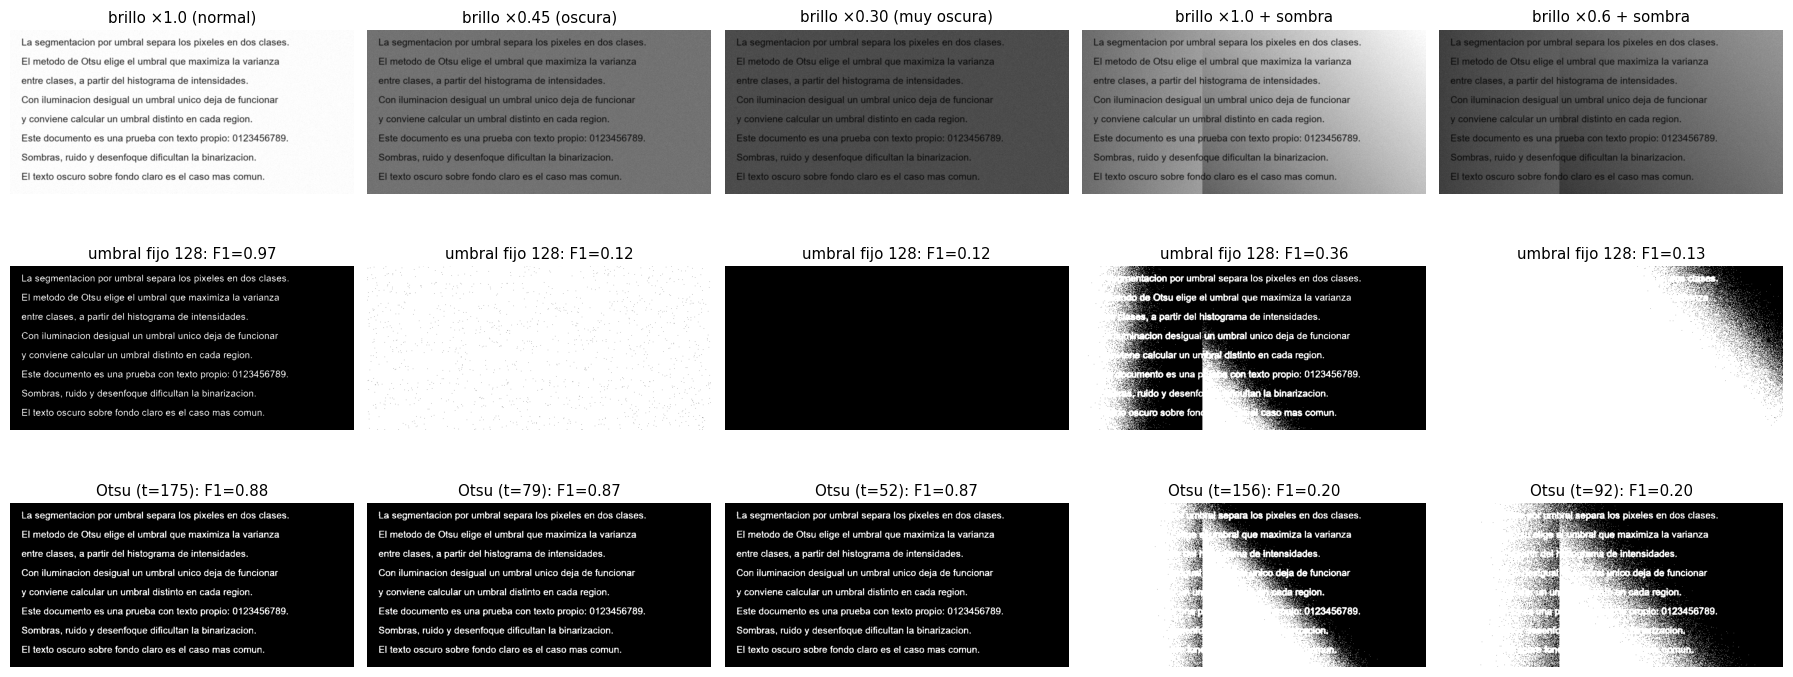

In [7]:
limpio = cv2.imread("data/documento_limpio.png", 0)
verdad = (limpio < 128).astype(np.uint8) * 255                      # texto = primer plano
rng = np.random.default_rng(1)

def toma(brillo=1.0, sombra=False, ruido=5, semilla=1):
    g = cv2.GaussianBlur(limpio.astype(np.float32), (0, 0), 0.7)
    if sombra:
        x = np.linspace(0, 1, g.shape[1])[None, :]; y = np.linspace(0, 1, g.shape[0])[:, None]
        g = g * np.clip(0.42 + 0.58 * x - 0.25 * y * (x > 0.35), 0.15, 1)      # degradado horizontal + sombra en la parte inferior derecha
    g = g * brillo + np.random.default_rng(semilla).normal(0, ruido, g.shape)
    return np.clip(g, 0, 255).astype(np.uint8)

print(f"{'condición':32s} {'umbral fijo 128 (F1)':>21s} {'Otsu (umbral)':>14s} {'Otsu (F1)':>10s} {'η':>6s}")
casos = {"brillo ×1.0 (normal)": toma(1.0), "brillo ×0.45 (oscura)": toma(0.45), "brillo ×0.30 (muy oscura)": toma(0.30), "brillo ×1.0 + sombra": toma(1.0, sombra=True), "brillo ×0.6 + sombra": toma(0.6, sombra=True)}
fig, ejes = plt.subplots(3, len(casos), figsize=(18, 7.6))
for j, (nombre, g) in enumerate(casos.items()):
    t, eta = eficacia(g)
    fijo = (g < 128).astype(np.uint8) * 255; otsu = (g <= t).astype(np.uint8) * 255
    print(f"{nombre:32s} {f1(fijo, verdad):21.3f} {t:14d} {f1(otsu, verdad):10.3f} {eta:6.3f}")
    ejes[0, j].imshow(g, cmap="gray", vmin=0, vmax=255); ejes[0, j].set_title(nombre)
    ejes[1, j].imshow(fijo, cmap="gray"); ejes[1, j].set_title(f"umbral fijo 128: F1={f1(fijo, verdad):.2f}")
    ejes[2, j].imshow(otsu, cmap="gray"); ejes[2, j].set_title(f"Otsu (t={t}): F1={f1(otsu, verdad):.2f}")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()


**Resultados y discusión.**
- **Con iluminación normal, un umbral fijo funciona incluso mejor que Otsu** (F1 = 0.968 frente a 0.883). Otsu elige t = 175, más alto que 128, e incluye como texto los píxeles grises del borde de las letras (suavizado), engrosando los trazos; parte de esta diferencia depende de que la verdad se definió con el umbral 128, es decir, de qué se considera «texto».
- **Cuando baja el brillo global, el umbral fijo se derrumba y Otsu se adapta.** Con la hoja oscurecida (×0.45 y ×0.30) el fondo queda por debajo de 128 y el umbral fijo lo clasifica todo como texto (F1 = 0.119 y 0.118), mientras que Otsu baja su umbral a 79 y 52 y mantiene F1 = 0.873 y 0.872. Esta es la principal ventaja de Otsu frente a un umbral único: **calcula el umbral a partir del histograma de cada imagen**.
- **Con sombra, ambos fallan** (Otsu: F1 = 0.197 y 0.205; umbral fijo: 0.360 y 0.130). Un umbral global no puede tratar a la vez la zona iluminada y la zona en sombra: Otsu separa «zona iluminada» de «zona en sombra» y no «texto» de «papel».
- Un aviso importante: con la sombra, la eficacia η sigue siendo moderadamente alta (0.62) aunque la segmentación es mala. **η mide qué tan bien separa el umbral dos grupos de intensidad, no si esos grupos corresponden a lo que se quiere segmentar**; por sí sola no basta para detectar un fallo.


<a id="estilos"></a>
## 3. Imágenes de fondos y estilos distintos

Se aplica Otsu a ocho imágenes de naturaleza distinta (fotografía, monedas, hoja de texto, radiografía, fluorescencia, microscopía de campo claro, resonancia y carretera). Como no hay una verdad de segmentación, se muestra el umbral, la eficacia $\eta$ y la fracción de píxeles que Otsu asigna al primer plano.

imagen                          umbral       η  % primer plano
Fotografía (cameraman)             102   0.857            67.9
Monedas                            107   0.756            38.8
Hoja de texto                      157   0.719            63.8
Radiografía                        113   0.748            48.8
Fluorescencia (canal verde)         84   0.839             4.3
Microscopía campo claro            130   0.835            71.6


Resonancia T2                       82   0.666            24.4
Carretera                          113   0.678            65.2


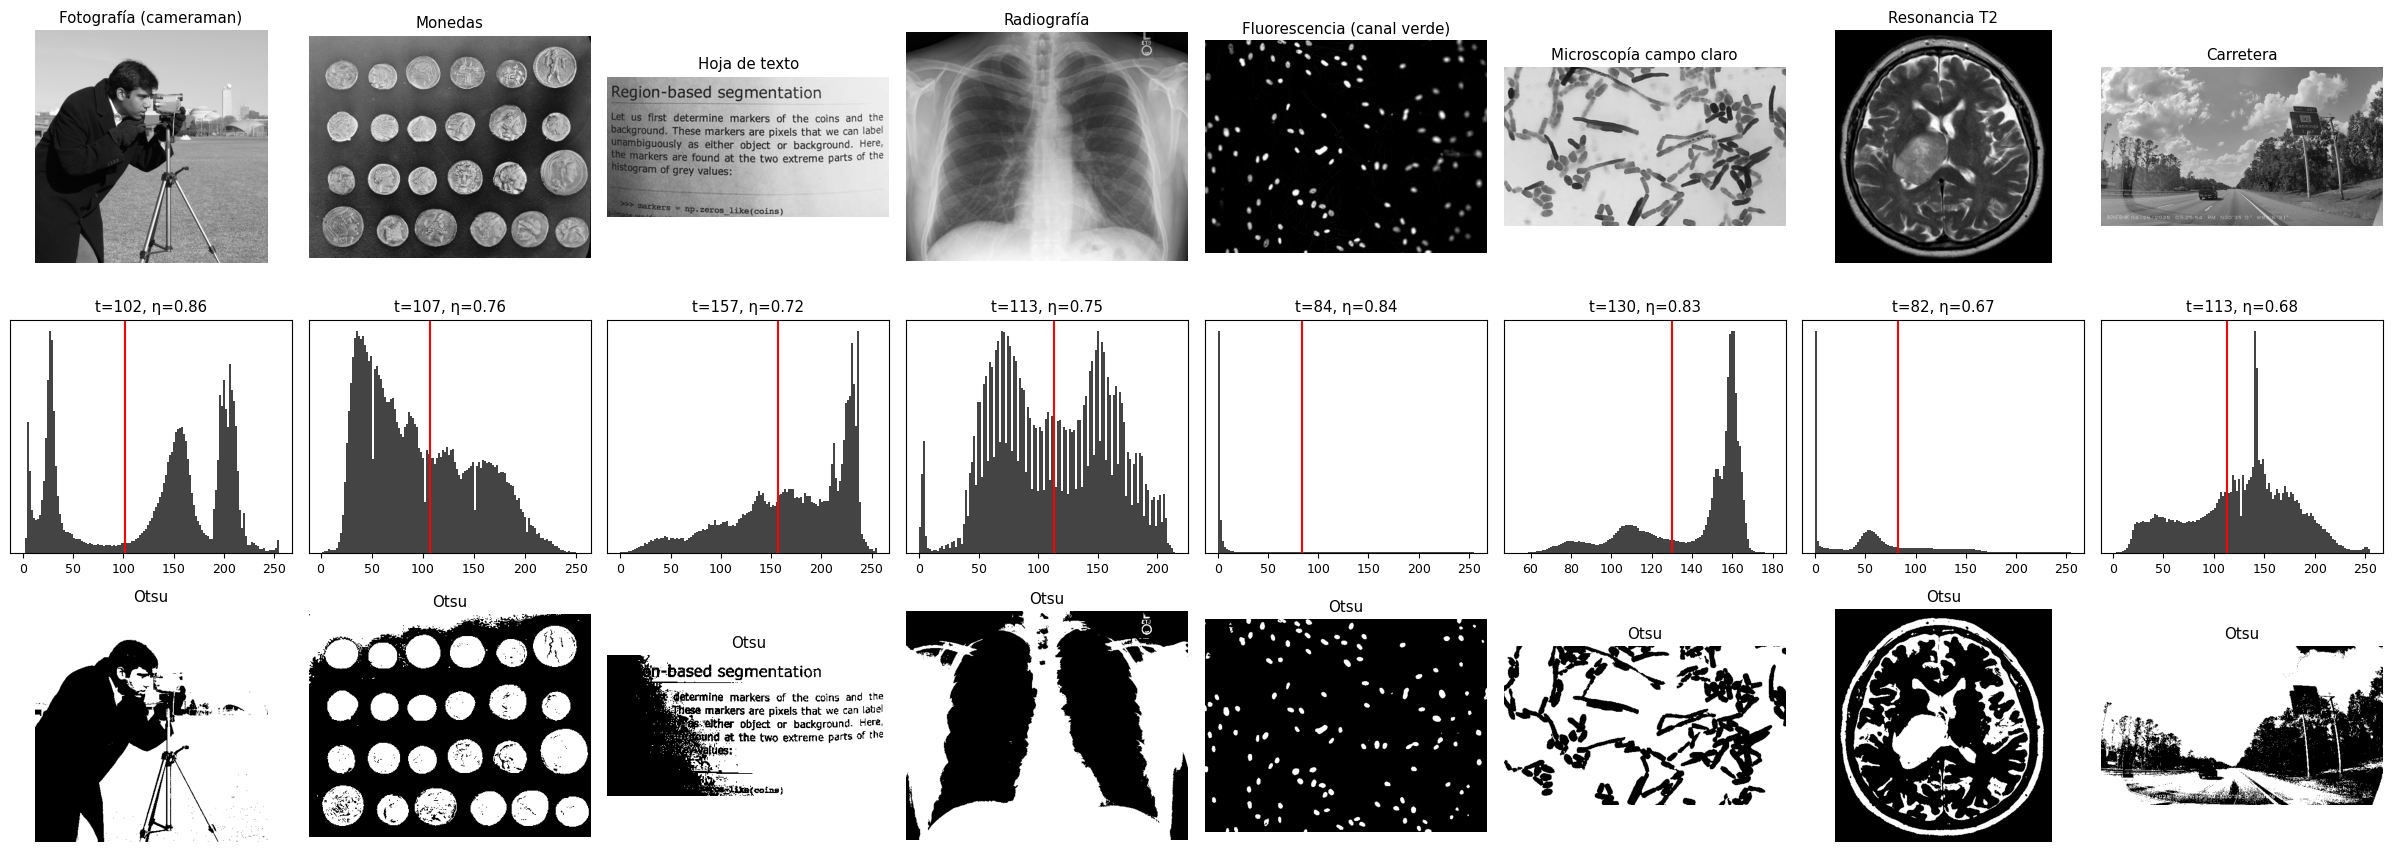

In [8]:
def gris_de(ruta, canal=None):
    im = cv2.imread(ruta)
    return im[..., canal] if canal is not None else cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

galeria = {"Fotografía (cameraman)": data.camera(), "Monedas": data.coins(), "Hoja de texto": data.page(), "Radiografía": gris_de("data/radiografia.jpg"),
           "Fluorescencia (canal verde)": gris_de("data/celulas.jpg", 1), "Microscopía campo claro": gris_de("data/microscopia.jpg"),
           "Resonancia T2": gris_de("data/resonancia_t2.jpg"), "Carretera": gris_de("data/carretera.jpg")}
fig, ejes = plt.subplots(3, 8, figsize=(24, 8.6))
print(f"{'imagen':30s} {'umbral':>7s} {'η':>7s} {'% primer plano':>15s}")
for j, (nombre, g) in enumerate(galeria.items()):
    g = g.astype(np.uint8); t, eta = eficacia(g); fg = (g > t)
    print(f"{nombre:30s} {t:7d} {eta:7.3f} {fg.mean() * 100:15.1f}")
    ejes[0, j].imshow(g, cmap="gray"); ejes[0, j].set_title(nombre); ejes[1, j].hist(g.ravel(), 128, color="#444"); ejes[1, j].axvline(t, color="r"); ejes[1, j].set_title(f"t={t}, η={eta:.2f}")
    ejes[2, j].imshow(fg, cmap="gray"); ejes[2, j].set_title("Otsu")
    ejes[0, j].axis("off"); ejes[2, j].axis("off"); ejes[1, j].set_yticks([])
plt.tight_layout(); plt.show()


**Resultados y discusión.** «Primer plano» aquí significa la clase de mayor intensidad, no necesariamente el objeto de interés.
- **Cuando el histograma es claramente bimodal, Otsu funciona muy bien.** El fotógrafo (η = 0.857, t = 102) separa la figura oscura del cielo claro; la fluorescencia (η = 0.839, t = 84) aísla los núcleos brillantes, que ocupan apenas el 4.3 % de la imagen, y se ve bien aunque las clases están muy desequilibradas porque están muy separadas en intensidad; las monedas (η = 0.756) se separan del fondo.
- **Con iluminación desigual falla:** en la hoja de texto (η = 0.719, t = 157) el umbral global deja negra buena parte de la zona izquierda (el 36.2 % de los píxeles queda como oscuro, muy por encima de la proporción real de texto) y se pierde el texto de esa región. Un η relativamente alto no lo evitó, pues las dos «clases» que separa son luz y sombra.
- **Con varias estructuras, dos clases no alcanzan.** En la radiografía (η = 0.748) Otsu separa los pulmones (oscuros) del resto del cuerpo, pero no distingue costillas, corazón ni lesiones; en la resonancia T2 (η = 0.666, el valor más bajo) separa el cerebro del fondo negro, pero los distintos tejidos y las lesiones quedan mezclados, para lo que haría falta multi-Otsu u otros métodos; en la carretera (η = 0.678) separa esencialmente cielo y suelo, no las marcas del pavimento.
- **La microscopía de campo claro** (η = 0.835) separa bien las células oscuras del fondo (71.6 % del área es fondo claro), pero el resultado queda «agujereado» por el interior claro de las células.
- Resumen de las limitaciones de un umbral único: (1) iluminación no uniforme, (2) más de dos clases, (3) histogramas no bimodales o muy desbalanceados, y (4) ruido, que ensancha los picos.


<a id="local"></a>
## 4. Opcional: Otsu por ventanas (umbral local)

En lugar de un solo umbral, se calcula uno **por píxel** con el histograma de una ventana centrada en él (`rank.otsu`, ventana circular de radio $r$). Se prueba con la hoja de papel de la práctica (`data.page()`) y con la hoja sintética con sombras, donde se conoce la verdad. Se compara con el umbral global de Otsu y con dos métodos locales clásicos (Sauvola y Niblack).

método                       F1    IoU  tiempo (ms)
Otsu global               0.205  0.114             
Otsu local r=5            0.288  0.168             
Otsu local r=10           0.334  0.200             
Otsu local r=20           0.459  0.298             
Otsu local r=40           0.551  0.380             
Otsu local r=80           0.608  0.437             
Otsu local r=120          0.668  0.501             
Otsu local r=160          0.728  0.572             
Sauvola (ventana 31)      0.846  0.734             
Niblack (ventana 31)      0.455  0.294             

tiempo Otsu local r=10: 96 ms (imagen de 900×430)


tiempo Otsu local r=40: 145 ms (imagen de 900×430)


tiempo Otsu local r=160: 328 ms (imagen de 900×430)


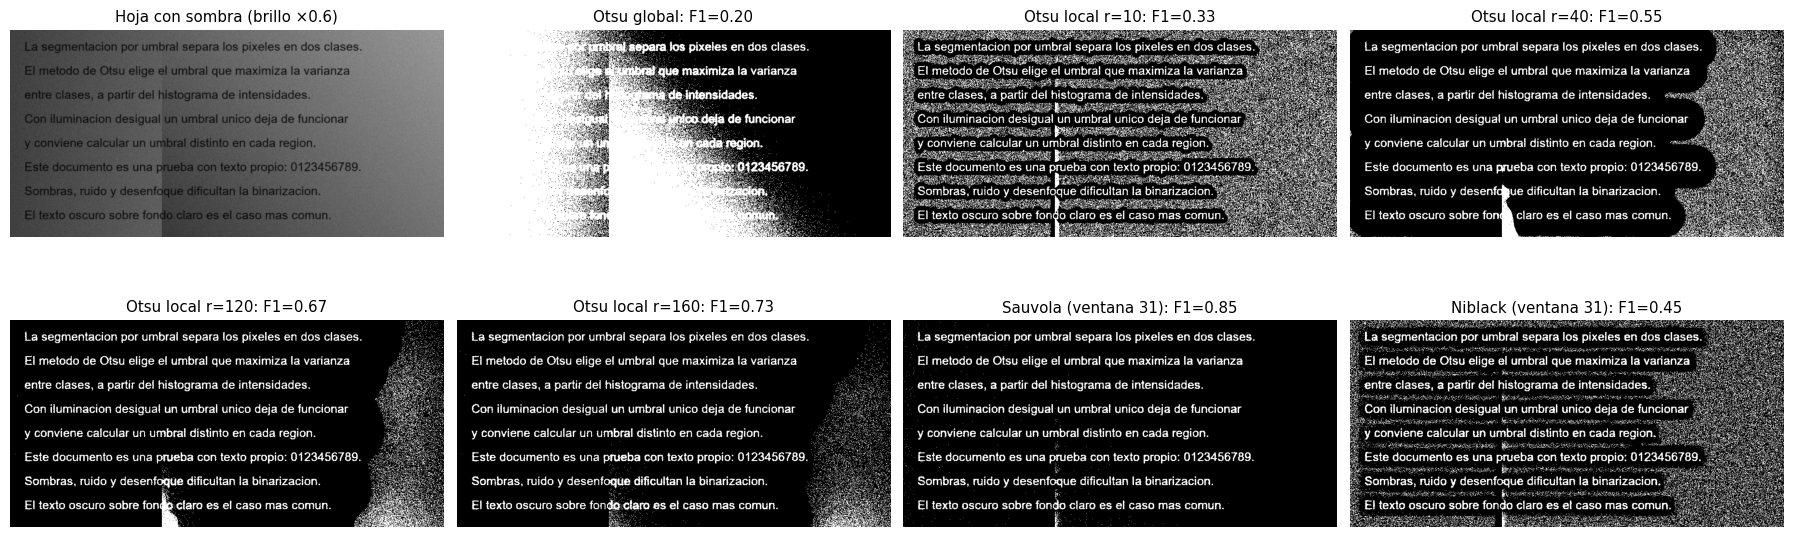

In [9]:
g = toma(0.6, sombra=True)
t_glob, _ = eficacia(g)
def otsu_local(gris, r):
    return (gris < rank.otsu(gris, disk(r))).astype(np.uint8) * 255      # texto oscuro: píxel por debajo de su umbral local

resultados = {"Otsu global": (g <= t_glob).astype(np.uint8) * 255}
for r_ in (5, 10, 20, 40, 80, 120, 160): resultados[f"Otsu local r={r_}"] = otsu_local(g, r_)
resultados["Sauvola (ventana 31)"] = (g < threshold_sauvola(g, window_size=31, k=0.2)).astype(np.uint8) * 255
resultados["Niblack (ventana 31)"] = (g < threshold_niblack(g, window_size=31, k=0.5)).astype(np.uint8) * 255
print(f"{'método':24s} {'F1':>6s} {'IoU':>6s} {'tiempo (ms)':>12s}")
for n, m in resultados.items(): print(f"{n:24s} {f1(m, verdad):6.3f} {iou(m, verdad):6.3f} {'':>12s}")
print()
for r_ in (10, 40, 160):
    t0 = time.perf_counter(); otsu_local(g, r_); print(f"tiempo Otsu local r={r_}: {(time.perf_counter() - t0) * 1000:.0f} ms (imagen de {g.shape[1]}×{g.shape[0]})")

fig, ejes = plt.subplots(2, 4, figsize=(18, 6.6))
ejes[0, 0].imshow(g, cmap="gray", vmin=0, vmax=255); ejes[0, 0].set_title("Hoja con sombra (brillo ×0.6)")
for a, n in zip(ejes.ravel()[1:], ("Otsu global", "Otsu local r=10", "Otsu local r=40", "Otsu local r=120", "Otsu local r=160", "Sauvola (ventana 31)", "Niblack (ventana 31)")):
    a.imshow(resultados[n], cmap="gray"); a.set_title(f"{n}: F1={f1(resultados[n], verdad):.2f}")
for a in ejes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

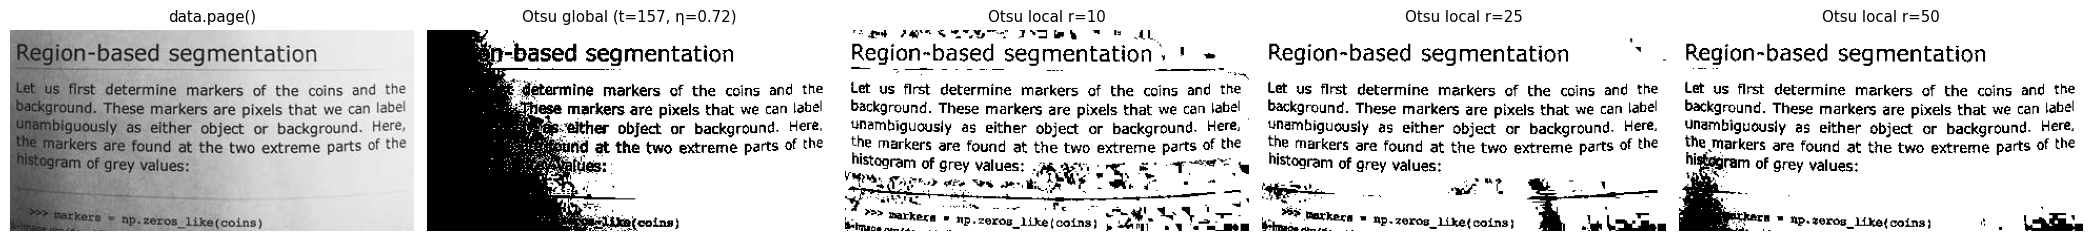

data.page(): tamaño (191, 384), fracción de píxeles oscuros con Otsu global: 36.2 %


In [10]:
# La hoja de papel de la práctica (skimage.data.page): umbral global frente a local
pag = data.page()
t_p, eta_p = eficacia(pag)
fig, ejes = plt.subplots(1, 5, figsize=(21, 3.6))
ejes[0].imshow(pag, cmap="gray"); ejes[0].set_title("data.page()")
ejes[1].imshow(pag > t_p, cmap="gray"); ejes[1].set_title(f"Otsu global (t={t_p}, η={eta_p:.2f})")
for a, r_ in zip(ejes[2:], (10, 25, 50)):
    a.imshow(pag >= rank.otsu(pag, disk(r_)), cmap="gray"); a.set_title(f"Otsu local r={r_}")
for a in ejes: a.axis("off")
plt.tight_layout(); plt.show()
print(f"data.page(): tamaño {pag.shape}, fracción de píxeles oscuros con Otsu global: {(pag <= t_p).mean() * 100:.1f} %")


**Resultados y discusión.**
- Sobre la hoja con sombra, el Otsu global obtiene F1 = 0.205. **El Otsu por ventanas mejora de forma continua al aumentar el radio**: 0.288 (r = 5), 0.334 (r = 10), 0.459 (r = 20), 0.551 (r = 40), 0.608 (r = 80), 0.668 (r = 120) y 0.728 (r = 160).
- Con ventanas pequeñas ocurre un problema conocido: muchas ventanas contienen solo fondo, y Otsu divide de todos modos el ruido en dos clases, lo que produce una nube de falsos píxeles de texto (se ve en r = 10 y r = 40). Con ventanas grandes, cada una contiene texto y fondo y el umbral es razonable, aunque un radio demasiado grande se parece cada vez más al umbral global y dejaría de seguir la sombra. En esta prueba el máximo fue en el radio mayor ensayado (160).
- **Sauvola (ventana de 31) obtuvo el mejor resultado (F1 = 0.846)** porque su umbral depende de la media y de la desviación estándar locales: donde la ventana es uniforme (solo fondo) la desviación es pequeña y el umbral queda por debajo del nivel del fondo, así que no aparece ruido. Niblack, que no tiene ese control, produjo mucho ruido de fondo (F1 = 0.455).
- **Costo:** el Otsu local tardó 94 ms con r = 10, 145 ms con r = 40 y 388 ms con r = 160, frente a unos pocos milisegundos del global; crece con el radio de la ventana.
- **La hoja de papel de la práctica (`data.page()`):** el Otsu global (t = 157) oscurece una gran parte de la izquierda, mientras que el Otsu local con r = 10, 25 y 50 recupera el texto en toda la hoja, con algo de ruido con la ventana más pequeña.


<a id="conclusion"></a>
## Conclusión


- **Otsu resuelve el problema de elegir el umbral automáticamente** a partir del histograma: al bajar el brillo del documento el umbral fijo de 128 cayó a F1 = 0.12, mientras que Otsu se mantuvo en 0.87.
- **Su límite es que asume dos clases separables por intensidad y una iluminación uniforme.** Falló con sombras (F1 = 0.20), con estructuras de más de dos clases (radiografía, resonancia) y con histogramas sin dos picos claros. La medida η del propio artículo orienta, pero no garantiza el éxito: con sombra siguió en 0.62.
- **El Otsu por ventanas corrige la iluminación desigual**, con el costo de más cómputo y de un parámetro (el radio) que debe ser mayor que los detalles y las zonas de fondo. Con ventanas pequeñas produce ruido; **Sauvola** superó a Otsu local (0.846 frente a 0.728) al usar también la desviación estándar local.
- Para varias clases existe multi-Otsu (incluido en el notebook base); para regiones de intensidad parecida hay que recurrir a otros métodos de segmentación (bordes, regiones, agrupamiento).
- **Limitaciones:** el documento y la sombra son sintéticos y se probó un solo patrón de sombra; los parámetros de Sauvola y Niblack no se ajustaron; la segmentación de las imágenes reales se evaluó de forma cualitativa.


## Referencias

- Otsu, N. (1979). A threshold selection method from gray-level histograms. *IEEE Transactions on Systems, Man, and Cybernetics, 9*(1), 62–66. https://doi.org/10.1109/TSMC.1979.4310076
- Sauvola, J., & Pietikäinen, M. (2000). Adaptive document image binarization. *Pattern Recognition, 33*(2), 225–236. https://doi.org/10.1016/S0031-3203(99)00055-2
- Niblack, W. (1986). *An introduction to digital image processing*. Prentice Hall.
- Liao, P.-S., Chen, T.-S., & Chung, P.-C. (2001). A fast algorithm for multilevel thresholding. *Journal of Information Science and Engineering, 17*(5), 713–727.
- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. (Cap. 10.)
- van der Walt, S., Schönberger, J. L., Nunez-Iglesias, J., Boulogne, F., Warner, J. D., Yager, N., Gouillart, E., & Yu, T. (2014). scikit-image: Image processing in Python. *PeerJ, 2*, e453. https://doi.org/10.7717/peerj.453
- Stanford Vision Lab. (s. f.). *Thresholding* [Tutorial]. https://ai.stanford.edu/~syyeung/cvweb/tutorial3.html
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons: Stillwaterising, Arnatbio, Chaurasiya, Hellerhoff y Rivera) e imágenes de ejemplo de scikit-image (`data.camera`, `data.coins`, `data.page`). El documento de prueba se genera con texto propio.